# Empirical Analysis

***

## Time-series Volatility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import ProjectConfig
from src.data_loader import MarketDataLoader
from src.returns import ReturnCalculator, ReturnConfig
from src.volatility_models import GJRGARCHModel, GARCHSpec, MultiAssetVolatilityFitter
from src.correlation_models import EWMACorrelation, EWMACorrSpec
from src.var_engine import VaREngine, VaRSpec
from src.backtest import VaRBacktester, BacktestSpec
from src.diagnostics import MultiAssetDiagnostics
from src.var_backtests import VaRBacktests, VaRTestSpec
from src.stress_testing import StressOverlay, StressSpec

In [2]:
cfg = ProjectConfig(
    tickers=["SPY", "TLT", "GLD", "LQD"],
    alpha=0.99,
    horizon_days=1,
    train_window=750,
    corr_window=252,
    ewma_lambda=0.97,
    n_sims=20000,
    random_seed=42
)

cfg.get_weights()

array([0.25, 0.25, 0.25, 0.25])

We’ll work with log-returns per asset 
𝑖:
$
r_{i,t}=\log(P_{i,t})-\log(P_{i,t-1})
$

Let the vector of returns be:
$
\mathbf r_t = (r_{1,t},\dots,r_{N,t})^\top
$

Given portfolio weights 
𝑤 (sum to 1), portfolio return:
$
r_{p,t}=\mathbf{w}^\top \mathbf{r}_t
$


In [3]:
cfg = ProjectConfig(
    tickers=["SPY", "TLT", "GLD", "LQD"],
    horizon_days=1
)

loader = MarketDataLoader(
    tickers=cfg.tickers,
    start_date=cfg.start_date,
    end_date=cfg.end_date
)

prices = loader.download_data()
prices = loader.clean_data()

prices.head()

Ticker,GLD,LQD,SPY,TLT
Date,,,,
2014-01-02,118.000000,75.326294,148.986023,73.561722
2014-01-03,119.290001,75.438263,148.961624,73.561722
2014-01-06,119.500000,75.602837,148.529999,73.871330
2014-01-07,118.820000,75.543564,149.442093,74.058533
2014-01-08,118.120003,75.220924,149.474747,73.856979


In [4]:
prices.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
GLD,3056.0,165.641057,66.519146,100.500000,120.647501,146.764999,179.482498,495.899994
LQD,3056.0,95.076706,10.794329,75.220970,86.834522,94.176685,104.034437,114.548615
SPY,3056.0,327.509465,148.350309,141.859268,196.148239,277.125534,420.003754,695.489990
TLT,3056.0,100.166750,16.201623,73.561714,88.212423,95.552151,106.876621,145.379333


In [5]:
cfg = ProjectConfig(tickers=["SPY", "TLT", "GLD", "LQD"], horizon_days=1)

# prices
loader = MarketDataLoader(cfg.tickers, cfg.start_date, cfg.end_date)
prices = loader.download_data()
prices = loader.clean_data()

# returns
rc = ReturnCalculator(ReturnConfig(log_returns=True, demean=False))
ret = rc.compute_asset_returns(prices)

w = cfg.get_weights()
rp = rc.compute_portfolio_returns(ret, w)

ret.head(), rp.head()

(Ticker           GLD       LQD       SPY       TLT
 Date                                              
 2014-01-03  0.010873  0.001485 -0.000164  0.000000
 2014-01-06  0.001759  0.002181 -0.002902  0.004200
 2014-01-07 -0.005707 -0.000785  0.006123  0.002531
 2014-01-08 -0.005909 -0.004280  0.000218 -0.002726
 2014-01-09  0.002874  0.002274  0.000654  0.005832,
 Date
 2014-01-03    0.003048
 2014-01-06    0.001309
 2014-01-07    0.000541
 2014-01-08   -0.003174
 2014-01-09    0.002908
 Name: portfolio_return, dtype: float64)

### Volatility models

Mean (zero for daily VaR baseline):
$
r_t = \epsilon_t
$

Shock decomposition:
$
\epsilon_t = \sigma_t z_t,\quad z_t\sim t_{\nu}
$

GJR-GARCH variance:
$
\sigma_t^2=\omega+\alpha \epsilon_{t-1}^2+\gamma \mathbf 1_{{\epsilon_{t-1}<0}}\epsilon_{t-1}^2+\beta \sigma_{t-1}^2
$

In [5]:
# compute returns
rc = ReturnCalculator(ReturnConfig(log_returns=True, demean=False))
ret = rc.compute_asset_returns(prices)

# fit per-asset GJR-GARCH-t
spec = GARCHSpec(p=1, o=1, q=1, dist="t", mean="Zero")
base_model = GJRGARCHModel(spec=spec, scale=100.0)

mvf = MultiAssetVolatilityFitter(base_model).fit(ret)

# outputs we will use later
sigma_t = mvf.conditional_vol_matrix()          # in-sample conditional vols
z_t = mvf.standardized_residual_matrix()        # standardized residuals
var_forecast = mvf.forecast_one_step_variances()# one-step variance forecasts

sigma_t.tail(), z_t.tail(), var_forecast

(                 GLD       LQD       SPY       TLT
 Date                                              
 2026-02-23  0.025180  0.002557  0.008055  0.006504
 2026-02-24  0.025478  0.002510  0.009538  0.006415
 2026-02-25  0.024726  0.002457  0.008858  0.006278
 2026-02-26  0.023902  0.002408  0.008255  0.006132
 2026-02-27  0.023229  0.002365  0.008343  0.006078,
                  GLD       LQD       SPY       TLT
 Date                                              
 2026-02-23  1.058639  0.420363 -1.274163  0.566443
 2026-02-24 -0.547766 -0.107014  0.759264  0.277701
 2026-02-25 -0.101530 -0.109339  0.948592  0.017720
 2026-02-26  0.357271  0.260275 -0.674741  0.651622
 2026-02-27  0.342587  0.680763 -0.720351  0.954085,
 GLD    0.000509
 LQD    0.000006
 SPY    0.000072
 TLT    0.000037
 Name: var_forecast, dtype: float64)

### Correlation model

- Standardized residuals (input)

$
\hat z_{i,t}=\frac{\hat\epsilon_{i,t}}{\hat\sigma_{i,t}}
$

Let $\hat{z}^t \in \mathbb{R}^N$.

- EWMA covariance and correlation

EWMA second-moment matrix:
$
S_t=\frac{\sum_{k=0}^{L-1}\lambda^k , \hat{\mathbf z}{t-k}\hat{\mathbf z}{t-k}^\top}{\sum_{k=0}^{L-1}\lambda^k}
$

Convert to correlation:
$
R_t = D_t^{-1} S_t D_t^{-1},\quad D_t=\mathrm{diag}(\sqrt{\mathrm{diag}(S_t)})
$

In [6]:
# z_t from Step 4: standardized residual matrix (T x N)
corr_spec = EWMACorrSpec(lam=cfg.ewma_lambda, window=cfg.corr_window)
corr_model = EWMACorrelation(corr_spec).fit(z_t)

R_t = corr_model.correlation_matrix()
R_t

array([[ 1.        , -0.05103066,  0.02447599, -0.06231552],
       [-0.05103066,  1.        ,  0.06880644,  0.90609858],
       [ 0.02447599,  0.06880644,  1.        , -0.05758516],
       [-0.06231552,  0.90609858, -0.05758516,  1.        ]])

### VaR engine module

- Conditional covariance construction

Let one-step-ahead variance forecasts be $\sigma^2_{i,t+1}$. Define:
$
D_{t+1}=\mathrm{diag}(\sigma_{1,t+1},\dots,\sigma_{N,t+1})
$

Given correlation estimate $R_t$, the conditional covariance is:
$
\Sigma_{t+1}=D_{t+1}R_tD_{t+1}
$

- Monte Carlo VaR definition

Simulate 𝑀 draws of portfolio return $r_{p}^{(m)}$.
Then:
$
\mathrm{VaR}{\alpha,1d}=-Q{1-\alpha}\left({r_{p}^{(m)}}_{m=1}^M\right)
$

Interpretation: VaR is a positive number (loss threshold). If returns are negative, losses are positive.

In [8]:
w = cfg.get_weights()
var_vec = var_forecast.loc[cfg.tickers].values  # ensure correct order

engine = VaREngine(VaRSpec(alpha=cfg.alpha, n_sims=cfg.n_sims, random_seed=cfg.random_seed))
VaR_1d, _, rp_sims = engine.compute_var_es(weights=w, var_forecast=var_vec, corr=R_t)

VaR_1d

0.014874942569826785

### Backtest module

We’ll implement a rolling 1-day VaR backtest that orchestrates your pipeline:

For each evaluation date $t$:
1. take a rolling training window of returns
2. fit per-asset GJR-GARCH-t
3. compute standardized residuals (in-sample) for correlation estimation
4. estimate $R_t$ via EWMA on standardized residuals
5. forecast $\sigma^2_{i,t+1}$ per asset
6. compute portfolio VaR for day $t+1$
7. compare VaR to realized ​$r_{p,t+1}$

- Realized portfolio return
$
r_{p,t+1} = \mathbf w^\top \mathbf r_{t+1}
$

- Exceedance indicator (VaR breach)
$
I_{t+1}=\mathbf 1{r_{p,t+1}<-\mathrm{VaR}_{\alpha,1d,t}}
$

In [9]:
w = cfg.get_weights()

bt_spec = BacktestSpec(
    train_window=cfg.train_window,
    corr_window=cfg.corr_window,
    ewma_lambda=cfg.ewma_lambda,
    alpha=cfg.alpha,
    n_sims=cfg.n_sims,
    random_seed=cfg.random_seed
)

backtester = VaRBacktester(bt_spec)
bt = backtester.run(ret, w)

summary = backtester.summarize(bt, alpha=cfg.alpha)
bt.head(), summary

(                 VaR        ES  realized_portfolio_return  breach
 date                                                             
 2016-12-27  0.010621  0.013245                   0.000817       0
 2016-12-28  0.010671  0.012997                   0.001360       0
 2016-12-29  0.010453  0.012882                   0.005055       0
 2016-12-30  0.010729  0.013670                  -0.001699       0
 2017-01-03  0.011149  0.013609                   0.005140       0,
 {'n_obs': 2305.0,
  'breaches': 27.0,
  'breach_freq': 0.011713665943600867,
  'expected_freq': 0.010000000000000009,
  'breach_freq_minus_expected': 0.0017136659436008585,
  'avg_VaR': 0.013264257519992365,
  'avg_ES': 0.01644555901369761})

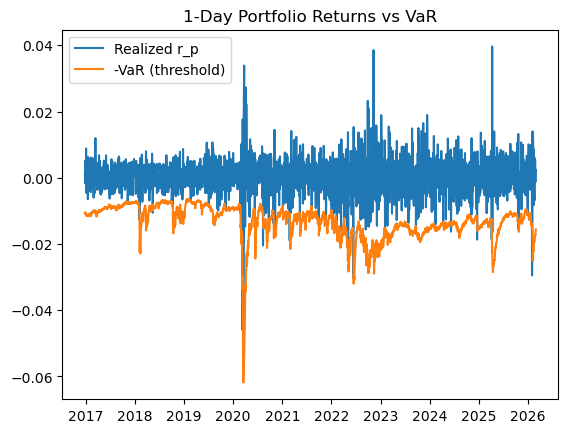

In [10]:
plt.figure()
plt.plot(bt.index, bt["realized_portfolio_return"], label="Realized r_p")
plt.plot(bt.index, -bt["VaR"], label="-VaR (threshold)")
plt.legend()
plt.title("1-Day Portfolio Returns vs VaR")
plt.savefig("return_vs_var.png",dpi=300)
plt.show()

### Diagnostics module

We check

- residual autocorrelation (should be small after fitting mean/vol)

- remaining ARCH effects in squared standardized residuals (should be reduced)

- basic persistence proxy for GJR-GARCH (high persistence is normal)

#### Standardized residuals

$
\hat z_t=\frac{\hat\epsilon_t}{\hat\sigma_t}
$

#### Ljung–Box statistic 

We test whether autocorrelations up to lag 𝑚 are jointly zero.
(We’ll compute p-values using a chi-square approximation.)

In [11]:
# mvf.models is a dict {ticker: fitted_model}
mad = MultiAssetDiagnostics()
diag_table = mad.run(mvf.models)
diag_table

,lb_Q_z,lb_p_z,lb_Q_z2,lb_p_z2,persistence_proxy
asset,,,,,
GLD,17.781883,0.601774,16.222225,0.702746,0.984711
LQD,32.418848,0.039035,34.017058,0.026010,0.983575
SPY,20.003178,0.457731,14.647055,0.796234,0.988748
TLT,20.017038,0.456864,10.462324,0.958994,0.987873


In [12]:
engine = VaREngine(
    VaRSpec(
        alpha=cfg.alpha,
        n_sims=cfg.n_sims,
        random_seed=cfg.random_seed,
        sim_dist="student_t",
        nu=8.0
    )
)

VaR_1d, ES_1d, rp_sims = engine.compute_var_es(
    weights=cfg.get_weights(),
    var_forecast=var_forecast.loc[cfg.tickers].values,
    corr=R_t
)

VaR_1d, ES_1d

(0.01619577459370438, 0.020210258976752427)

### VaR backtests: Kupiec + Christoffersen

Let $I_t \in \{0,1\}$	​be the breach indicator and $p=1-\alpha$.

- Kupiec (Unconditional Coverage) tests whether breach frequency equals $p$.

- Christoffersen (Independence) tests whether breaches cluster via a 2-state Markov chain.

In [13]:
cfg = ProjectConfig(tickers=["SPY","TLT","GLD","LQD"], horizon_days=1, alpha=0.99, n_sims=20000)

loader = MarketDataLoader(cfg.tickers, cfg.start_date, cfg.end_date)
prices = loader.download_data()
prices = loader.clean_data()

rc = ReturnCalculator(ReturnConfig(log_returns=True, demean=False))
ret = rc.compute_asset_returns(prices)

w = cfg.get_weights()

bt_spec = BacktestSpec(
    train_window=cfg.train_window,
    corr_window=cfg.corr_window,
    ewma_lambda=cfg.ewma_lambda,
    alpha=cfg.alpha,
    n_sims=cfg.n_sims,
    random_seed=cfg.random_seed,
    sim_dist="student_t",
    nu=8.0
)

bt = VaRBacktester(bt_spec).run(ret, w)
summary = VaRBacktester.summarize(bt, alpha=cfg.alpha)
summary

{'n_obs': 2305.0,
 'breaches': 27.0,
 'breach_freq': 0.011713665943600867,
 'expected_freq': 0.010000000000000009,
 'breach_freq_minus_expected': 0.0017136659436008585,
 'avg_VaR': 0.013264129611586694,
 'avg_ES': 0.01644541861691478}

#### Plot realized vs threshold and breaches

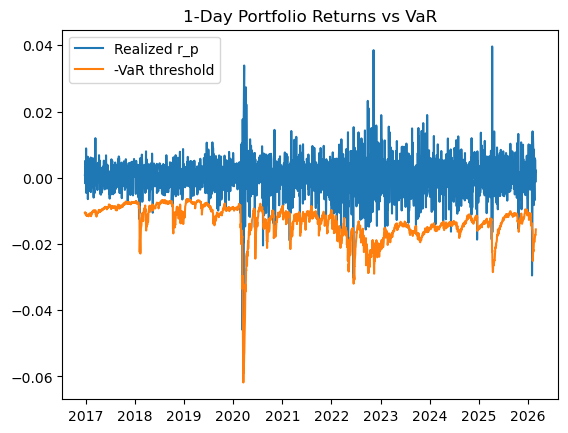

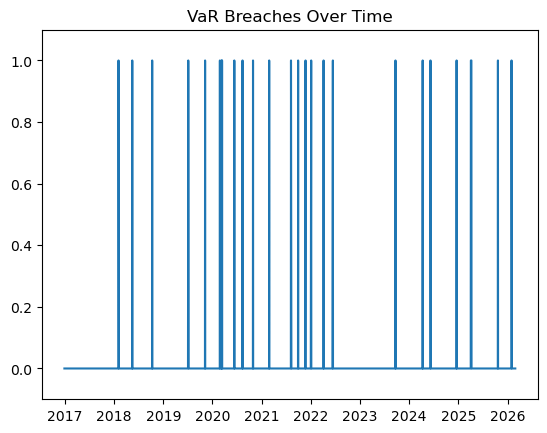

In [14]:
plt.figure()
plt.plot(bt.index, bt["realized_portfolio_return"], label="Realized r_p")
plt.plot(bt.index, -bt["VaR"], label="-VaR threshold")
plt.legend()
plt.title("1-Day Portfolio Returns vs VaR")
plt.show()

plt.figure()
plt.plot(bt.index, bt["breach"], label="Breach (0/1)")
plt.ylim(-0.1, 1.1)
plt.title("VaR Breaches Over Time")
plt.savefig('var_t.png',dpi=300)
plt.show()

### Kupiec + Christoffersen

In [15]:
tests = VaRBacktests(VaRTestSpec(alpha=cfg.alpha))
uc = tests.kupiec_uc(bt["breach"])
ind = tests.christoffersen_ind(bt["breach"])
cc = tests.christoffersen_cc(bt["breach"])
uc, ind, cc

({'n': 2305.0,
  'x': 27.0,
  'p': 0.010000000000000009,
  'phat': 0.011713665943600867,
  'LR_uc': 0.6480805168633879,
  'p_value_uc': 0.42079978190119227},
 {'n00': 2252.0,
  'n01': 25.0,
  'n10': 25.0,
  'n11': 2.0,
  'pi': 0.011713665943600867,
  'pi01': 0.010979358805445762,
  'pi11': 0.07407407407407407,
  'LR_ind': 4.2266452679076,
  'p_value_ind': 0.03979402119564146},
 {'LR_cc': 4.8747257847709875,
  'p_value_cc': 0.08739100734659477,
  'uc_n': 2305.0,
  'uc_x': 27.0,
  'uc_p': 0.010000000000000009,
  'uc_phat': 0.011713665943600867,
  'uc_LR_uc': 0.6480805168633879,
  'uc_p_value_uc': 0.42079978190119227,
  'ind_n00': 2252.0,
  'ind_n01': 25.0,
  'ind_n10': 25.0,
  'ind_n11': 2.0,
  'ind_pi': 0.011713665943600867,
  'ind_pi01': 0.010979358805445762,
  'ind_pi11': 0.07407407407407407,
  'ind_LR_ind': 4.2266452679076,
  'ind_p_value_ind': 0.03979402119564146})

### Stress testing overlay

This is a risk overlay applied to the forecast inputs Σ (via vol multipliers + correlation stress) and recompute VaR/ES.

Vol shock:
$
\sigma^{\text{stress}}_i = m_{\sigma,i}
$
so variance scales by $m^2_{\sigma,i}$

Correlation upshift (linear blend toward “crisis correlation” target $R^*$
$
R^{\text{stress}} = (1-\kappa)R + \kappa R^*
$

Pick a representative date near the end: Reuse the last rolling window logic or do a single “as-of today” fit.

In [6]:
from src.volatility_models import GJRGARCHModel, GARCHSpec, MultiAssetVolatilityFitter
from src.correlation_models import EWMACorrelation, EWMACorrSpec
from src.var_engine import VaREngine, VaRSpec

train = ret.iloc[-cfg.train_window:].copy()

mvf = MultiAssetVolatilityFitter(
    GJRGARCHModel(GARCHSpec(p=1,o=1,q=1,dist="t",mean="Zero"), scale=100.0)
).fit(train)

z = mvf.standardized_residual_matrix()
R = EWMACorrelation(EWMACorrSpec(lam=cfg.ewma_lambda, window=cfg.corr_window)).fit(z).correlation_matrix()
var_fc = mvf.forecast_one_step_variances().loc[ret.columns].values

engine = VaREngine(VaRSpec(alpha=cfg.alpha, n_sims=cfg.n_sims, random_seed=cfg.random_seed, sim_dist="student_t", nu=8.0))
VaR_base, ES_base, _ = engine.compute_var_es(cfg.get_weights(), var_fc, R)

overlay = StressOverlay(StressSpec(vol_multiplier=1.5, corr_blend=0.3))
var_stress, R_stress = overlay.apply(var_fc, R)

VaR_stress, ES_stress, _ = engine.compute_var_es(cfg.get_weights(), var_stress, R_stress)

{"VaR_base": VaR_base, "ES_base": ES_base, "VaR_stress": VaR_stress, "ES_stress": ES_stress}

{'VaR_base': 0.014019533306808902,
 'ES_base': 0.01723968455610965,
 'VaR_stress': 0.020917386346524344,
 'ES_stress': 0.02581911377994209}